# Statistical Analysis for Machine Learning

This notebook introduces basic statistical concepts that are important in data science and machine learning.  
We won’t go into deep mathematical details — the goal is to build intuition and prepare for later topics like fitting, correlation, and ML models.

## 1. Why Statistics in ML?

Machine Learning is not just about building models — it’s about understanding data.  
Statistics helps us:
- Summarise data (mean, variance, distribution)
- Detect patterns over random noise
- Make inferences about populations from samples
- Test whether relationships are meaningful

Before we fit models, we need to know what our data is *telling us*.

In [3]:
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

# Load Titanic dataset (available locally)

titanic = pd.read_csv("./data/titanic3.csv")

In [4]:
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 2. Descriptive vs Inferential Statistics

- **Descriptive statistics**: Describe and summarise data. (e.g., mean age of passengers)  
- **Inferential statistics**: Make generalisations or decisions based on data. (e.g., Did women have higher survival rates than men, beyond random chance?)  

We’ll explore both briefly.

In [6]:
# Descriptive statistics
titanic[['age', 'fare']].describe()


,age,fare
count,1046.000000,1308.000000
mean,29.881135,33.295479
std,14.413500,51.758668
min,0.166700,0.000000
25%,21.000000,7.895800
50%,28.000000,14.454200
75%,39.000000,31.275000
max,80.000000,512.329200


## 3. Distributions and Variability

Understanding how data is distributed is key before modeling.

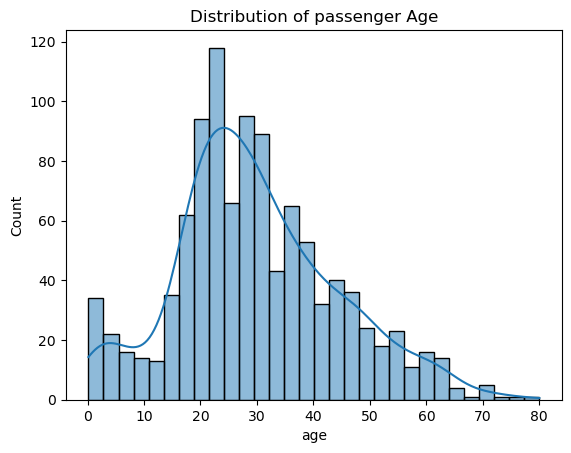

In [8]:
sns.histplot(titanic['age'].dropna(), bins=30, kde=True)
plt.title("Distribution of passenger Age")
plt.show()


## 4. Hypothesis Testing (Conceptual)

Hypothesis testing is a statistical method used to make inferences about a population based on a sample of data. It involves the formulation of two competing hypotheses, the null hypothesis (H0) and the alternative hypothesis (H1), and then using statistical methods to decide whether there is enough evidence to reject the null hypothesis in favor of the alternative hypothesis.

Hypothesis testing helps us answer questions like:

- *Is the difference we see real, or just random chance?*  
- *Does a variable truly affect the outcome?*


We define:
- **Null hypothesis (H₀):** There is no effect / no difference.  
- **Alternative hypothesis (H₁):** There is a real effect.  

The goal is to test a claim (the null hypothesis) against an alternative claim (the alternative hypothesis) and decide whether there is enough evidence to reject the null hypothesis.



### Example: testing is survival is independent on gender:
We often want to know whether two variables are related.  
Here: **Sex** (male/female) and **Survived** (0/1).  

- Null hypothesis (H₀): Survival is independent of gender.  
- Alternative hypothesis (H₁): Survival depends on gender.  

To test this, we use a **Chi-square test of independence**, which compares observed counts with expected counts (if the variables were unrelated).  

In [10]:
import scipy.stats as stats

# Create a contingency table (cross-tabulation)
# Rows = Sex, Columns = Survival outcome

contingency = pd.crosstab(titanic['sex'], titanic['survived'])
print(contingency)

# Run the Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency)


#write code here


survived    0    1
sex               
female    127  339
male      682  161


In [11]:
chi2

np.float64(363.6179084388249)

In [12]:
p

np.float64(4.589924936952945e-81)


The **Chi-square statistic** measures how different the observed survival counts are from what we would expect if gender had no effect.  
The **p-value** tells us the probability of observing a difference at least this extreme if the null hypothesis (no relationship) were true. 

- If p < 0.05 → strong evidence that survival is related to gender.  
- If p ≥ 0.05 → no evidence of a relationship (at least in this sample).

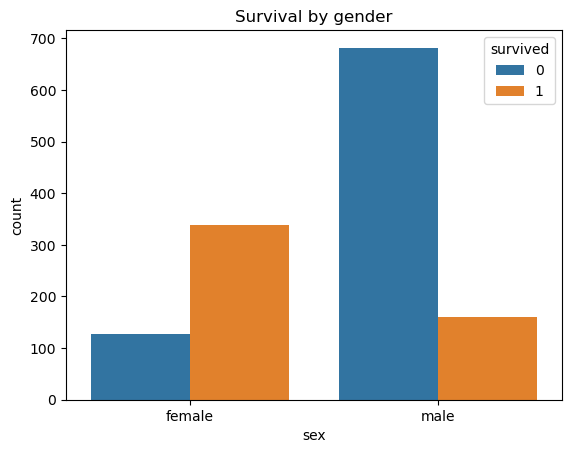

In [13]:
sns.countplot(data=titanic, x='sex', hue='survived')
plt.title("Survival by gender")
plt.show()

Finally, a plot helps us see the relationship visually:
- The bar chart below shows survival rates by gender.
- Even without the formal test, we can already see a difference.


In [5]:
#write code here


#### Interpretation:

Results may vary based on the dataset that you use. Typical values are:

Chi² statistic: very large (≈ 260)
p-value: extremely small (on the order of 10⁻⁵⁸)

##### Conclusion:
Since the p-value is far below 0.05, we reject the null hypothesis.
This means survival is strongly associated with gender — women had a much higher chance of survival than men.


The bar plot of Sex × Survived confirms this visually:
- The majority of women survived.
- The majority of men did not.

This is a classic example where both the statistics and the visualization tell the same story.

#### Summary: 
Key Concepts:

**Null Hypothesis (H0)**:


The null hypothesis represents a statement of no effect or no difference.
Denoted as H0, it is typically what researchers aim to test against.


**Alternative Hypothesis (H1)**:

The alternative hypothesis represents the opposite of the null hypothesis.
Denoted as H1, it reflects the researcher's claim or the presence of an effect.


**Significance Level (α)**:

The significance level, often denoted as α, is the probability of rejecting the null hypothesis when it is true.
Common choices for α are 0.05 or 5%.


**Test Statistic**:

A test statistic is a numerical value computed from the sample data, used to decide whether to reject the null hypothesis.


**P-value**:

The p-value is the probability of observing a test statistic as extreme as, or more extreme than, the one computed from the sample data, assuming the null hypothesis is true.
A lower p-value suggests stronger evidence against the null hypothesis.


## 5. Why This Matters for ML

- Before fitting models, we use statistics to **explore data quality** and **spot relationships**.  
- Statistical tests help avoid mistaking random noise for a real pattern.  
- Many ML concepts (loss functions, evaluation metrics) are rooted in statistical ideas.  

 Next, we’ll move into **fitting and correlation**, where we’ll quantify and visualize relationships in data.